# Feature Binning:

Feature binning is a data preprocessing and visualization technique that groups continuous numerical data into discrete ranges (bins). In machine learning, it transforms numerical variables into categorical ones, reducing noise and improving model performance.

#### In Machine Learning
- Transformation: Binning converts continuous data (e.g., age, income) into discrete categories (e.g., "young adult," "middle-aged," "senior"). 
- Non-linearity: It can introduce non-linearity into models, which can improve their performance. 
- Outlier Handling: It reduces the impact of outliers and skewed data distributions by grouping them into bins. 
- Example:
Instead of representing "Age" with its raw numerical value, feature binning might group ages into bins like 0-18, 19-35, 36-60, etc., which the model can then process.

#### Common Binning Methods:
- Equal-Width Binning:
This method divides the entire range of the feature into a specified number of bins, where each bin has the same width.
It is suitable for data with a relatively uniform distribution.
- Equal-Frequency Binning (Quantile Binning):
This method creates bins that contain approximately the same number of observations or data points. 
It is particularly useful for skewed data, as it ensures a balanced representation across categories, even if the bin widths vary.
- Custom Binning:
This method allows for the definition of custom bin edges based on domain knowledge, specific thresholds, or business requirements.
It is ideal when there are meaningful cut-off points within the data.
- Logarithmic Binning:
This method involves applying a logarithmic transformation to the data before performing equal-width binning.
It is useful for features with a wide range of values or an exponential distribution, as it creates bins that grow exponentially in size.
- K-Means Binning:
This method utilizes the K-Means clustering algorithm to group data points into a specified number of clusters, and each cluster then represents a bin.
It aims to create bins where data points within each bin are as similar as possible.
- Entropy-Based Binning (Supervised Binning):
Unlike the unsupervised methods above, entropy-based binning considers the target variable (in supervised learning) to determine optimal bin boundaries.
It aims to create bins that maximize the information gain or minimize the entropy with respect to the target variable.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('Churn_Modelling.csv')

In [46]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [48]:
df.describe()['Age']

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

#### 1) Equal-Width Binning (Fixed-Width Binning):

##### 1) Using Function:

In [49]:
def age_bins(age):
    if age < 10:
        return '0-9'
    elif age < 20:
        return '10-19'
    elif age < 30:
        return '20-29'
    elif age < 40:
        return '30-39'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    elif age < 70:
        return '60-69'
    elif age < 80:
        return '70-79'
    elif age < 90:
        return '80-89'
    elif age < 100:
        return '90-99'
    else:
        return 'Above 100'

In [50]:
df['Age_Bins'] = df['Age'].apply(age_bins)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Bins
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,40-49
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,40-49
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40-49
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-39
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,40-49


In [51]:
df['Age_Bins'].value_counts()

Age_Bins
30-39    4346
40-49    2618
20-29    1592
50-59     869
60-69     375
70-79     136
10-19      49
80-89      13
90-99       2
Name: count, dtype: int64

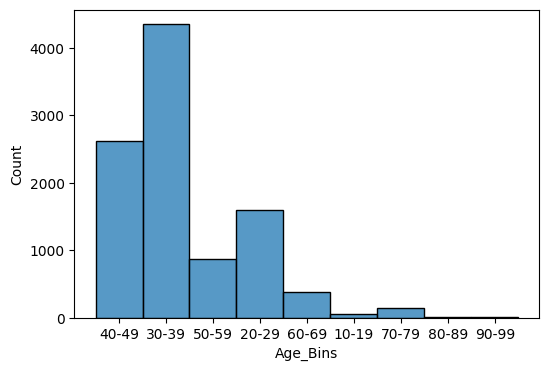

In [52]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Age_Bins')
plt.show()

##### 2) Using pd.cut:

In [53]:
df['Age_Bins'] = pd.cut(x= df['Age'], bins= 10)

In [54]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Bins
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,"(40.2, 47.6]"
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,"(40.2, 47.6]"
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,"(40.2, 47.6]"
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,"(32.8, 40.2]"
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,"(40.2, 47.6]"


In [55]:
df['Age_Bins'].value_counts()

Age_Bins
(32.8, 40.2]      3629
(25.4, 32.8]      2179
(40.2, 47.6]      1871
(47.6, 55.0]       910
(17.926, 25.4]     611
(55.0, 62.4]       441
(62.4, 69.8]       208
(69.8, 77.2]       127
(77.2, 84.6]        20
(84.6, 92.0]         4
Name: count, dtype: int64

#### 2) Equal-Frequency Binning (Quantile Binning):

In [56]:
df['Age_Bins_Q'] = pd.qcut(x= df['Age'], q= 10)

In [57]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Bins,Age_Bins_Q
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,"(40.2, 47.6]","(40.0, 42.0]"
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,"(40.2, 47.6]","(40.0, 42.0]"
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,"(40.2, 47.6]","(40.0, 42.0]"
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,"(32.8, 40.2]","(37.0, 40.0]"
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,"(40.2, 47.6]","(42.0, 46.0]"


In [58]:
df['Age_Bins_Q'].value_counts()

Age_Bins_Q
(27.0, 31.0]      1352
(37.0, 40.0]      1332
(17.999, 27.0]    1020
(42.0, 46.0]      1009
(53.0, 92.0]       966
(35.0, 37.0]       934
(33.0, 35.0]       921
(46.0, 53.0]       919
(31.0, 33.0]       860
(40.0, 42.0]       687
Name: count, dtype: int64

#### 3) Custom Binning (User-Defined Binning):

In [59]:
bins_custom = [0, 10, 20, 30 ,40, 50 ,60, 70 ,80, 90, 100]
labels_custom = ['0-10', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99']

In [63]:
df['Age_Bins_Custom'] = pd.cut(x= df['Age'], bins= bins_custom, labels= labels_custom, right= False)

In [64]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Bins,Age_Bins_Q,Age_Bins_Custom
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,"(40.2, 47.6]","(40.0, 42.0]",40-49
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,"(40.2, 47.6]","(40.0, 42.0]",40-49
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,"(40.2, 47.6]","(40.0, 42.0]",40-49
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,"(32.8, 40.2]","(37.0, 40.0]",30-39
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,"(40.2, 47.6]","(42.0, 46.0]",40-49


In [65]:
df['Age_Bins_Custom'].value_counts()

Age_Bins_Custom
30-39    4346
40-49    2618
20-29    1592
50-59     869
60-69     375
70-79     136
10-19      49
80-89      13
90-99       2
0-10        0
Name: count, dtype: int64

#### 4) Logarithmic Binning:

In [68]:
df['Age_Log'] = np.log(df['Age'])
df['Age_Bins_Log'] = pd.cut(x= df['Age_Log'], bins= 10)

In [69]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Bins,Age_Bins_Q,Age_Bins_Custom,Age_Bins_Log,Age_Log
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,"(40.2, 47.6]","(40.0, 42.0]",40-49,"(3.706, 3.869]",3.737670
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,"(40.2, 47.6]","(40.0, 42.0]",40-49,"(3.706, 3.869]",3.713572
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,"(40.2, 47.6]","(40.0, 42.0]",40-49,"(3.706, 3.869]",3.737670
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,"(32.8, 40.2]","(37.0, 40.0]",30-39,"(3.543, 3.706]",3.663562
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,"(40.2, 47.6]","(42.0, 46.0]",40-49,"(3.706, 3.869]",3.761200


In [70]:
df['Age_Bins_Log'].value_counts()

Age_Bins_Log
(3.543, 3.706]    2740
(3.38, 3.543]     2038
(3.706, 3.869]    1871
(3.217, 3.38]     1184
(3.869, 4.032]     980
(4.032, 4.196]     501
(3.054, 3.217]     315
(4.196, 4.359]     210
(2.889, 3.054]     142
(4.359, 4.522]      19
Name: count, dtype: int64